In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# 1. Load the MSCAD dataset
# Ensure 'MSCAD.xlsx' is in your working directory
df = pd.read_csv('/kaggle/input/mscad/MSCAD Dataset/MSCAD Dataset/CSV/CSV/MSCAD.csv')

# 2. Quick look at the data
print("Dataset shape:", df.shape)
df.head()
# 1. Load the MSCAD dataset
# Ensure 'MSCAD.xlsx' is in your working directory
df = pd.read_csv('/kaggle/input/mscad/MSCAD Dataset/MSCAD Dataset/CSV/CSV/MSCAD.csv')

# 2. Quick look at the data
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (128799, 67)
Dataset shape: (128799, 67)


,'Flow Duration','Tot Fwd Pkts','Tot Bwd Pkts','TotLen Fwd Pkts','TotLen Bwd Pkts','Fwd Pkt Len Max','Fwd Pkt Len Min','Fwd Pkt Len Mean','Fwd Pkt Len Std','Bwd Pkt Len Max',...,'Fwd Act Data Pkts','Active Mean','Active Std','Active Max','Active Min','Idle Mean','Idle Std','Idle Max','Idle Min',Label
0,1518,2,5,110,377,110,0,55.0,77.7817,377,...,1,0,0,0,0,0,0,0,0,Brute_Force
1,5894,4,8,168,4498,168,0,42.0,84.0000,1460,...,1,0,0,0,0,0,0,0,0,Brute_Force
2,272,1,1,0,0,0,0,0.0,0.0000,0,...,0,0,0,0,0,0,0,0,0,Brute_Force
3,2611,4,8,322,4434,322,0,80.5,161.0000,1460,...,1,0,0,0,0,0,0,0,0,Brute_Force
4,294,1,1,0,0,0,0,0.0,0.0000,0,...,0,0,0,0,0,0,0,0,0,Brute_Force


Dataset shape: (128799, 67)
Accuracy: 0.9972
Precision: 0.9973
Recall: 0.9972
F1 Score: 0.9972
Confusion Matrix:
 [[35389     4     0     5     3     0]
 [    1   239     0     9     7     0]
 [    0     1    15     1     0     1]
 [   10     9     3 11368    10     1]
 [   25    17     5    23  4363     0]
 [    0     1     0     6     0     4]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     35401
           1       0.88      0.93      0.91       256
           2       0.65      0.83      0.73        18
           3       1.00      1.00      1.00     11401
           4       1.00      0.98      0.99      4433
           5       0.67      0.36      0.47        11

    accuracy                           1.00     51520
   macro avg       0.87      0.85      0.85     51520
weighted avg       1.00      1.00      1.00     51520



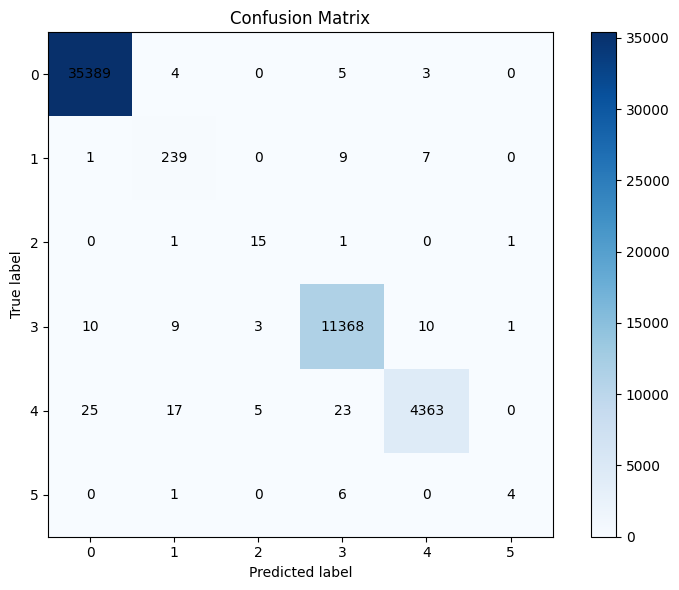

In [4]:


# 3. Preprocessing: handle categorical features
# Identify object (categorical) columns
cat_cols = df.select_dtypes(include=['object']).columns
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

# 4. Split features and target
X = df.drop('Label', axis=1)  # replace 'label' with the actual name of the class column
y = df['Label']

# 5. Train-test split: 60% training, 40% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# 6. Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Train KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)  # adjust k as needed
knn.fit(X_train_scaled, y_train)

# 8. Make predictions
y_pred = knn.predict(X_test_scaled)

# 9. Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Confusion Matrix:\n", cm)

# 10. Detailed Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

# 11. Plot confusion matrix heatmap
plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
classes = np.unique(y)
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)
plt.ylabel('True label')
plt.xlabel('Predicted label')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.tight_layout()
plt.show()
